
# 製造ライン KPI可視化・分析

## このノートブックについて

製造業での生産管理・品質管理の実務経験をもとに、日々の生産実績データから
**不良率・稼働率・OEE（設備総合効率）** などのKPIを算出し、可視化するポートフォリオです。

Python未経験・データ分析未経験からのキャリアチェンジに向けて、
`pandas` によるデータ加工と `matplotlib` による可視化を練習することを目的としています。

> **データについて**：使用しているデータは、実務の傾向感（ラインごとの不良率の違い・
> 設備トラブルの発生パターンなど）を反映しつつ、`data/generate_data.py` で生成した
> 疑似データです。実データではありません（乱数シード固定・再現可能）。

## 分析の流れ
1. データ読み込み・確認
2. KPI算出（不良率・良品率・稼働率・OEE）
3. ライン別・日別のトレンド可視化
4. 不良原因のパレート分析
5. 分析から見えた示唆のまとめ


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# 日本語フォント設定（Noto Sans CJK JP）
plt.rcParams["font.family"] = "Noto Sans CJK JP"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110

pd.set_option("display.max_columns", None)


## 1. データ読み込み・確認

In [2]:

daily = pd.read_csv("../data/production_daily.csv", parse_dates=["date"])
defects = pd.read_csv("../data/defect_detail.csv", parse_dates=["date"])

print("production_daily:", daily.shape)
print("defect_detail   :", defects.shape)
daily.head()


production_daily: (192, 8)
defect_detail   : (932, 4)


,date,line,planned_output_qty,actual_output_qty,good_qty,defect_qty,planned_minutes,actual_operating_minutes
0,2026-05-01,Aライン,1210,1133,1116,17,480,441.2
1,2026-05-04,Aライン,1169,1120,1093,27,480,459.6
2,2026-05-05,Aライン,1231,1140,1112,28,480,450.7
3,2026-05-06,Aライン,1213,1199,1176,23,480,455.2
4,2026-05-07,Aライン,1195,1117,1092,25,480,443.1


In [3]:

# 欠損値・型の確認
daily.info()


<class 'pandas.DataFrame'>
RangeIndex: 192 entries, 0 to 191
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   date                      192 non-null    datetime64[us]
 1   line                      192 non-null    str           
 2   planned_output_qty        192 non-null    int64         
 3   actual_output_qty         192 non-null    int64         
 4   good_qty                  192 non-null    int64         
 5   defect_qty                192 non-null    int64         
 6   planned_minutes           192 non-null    int64         
 7   actual_operating_minutes  192 non-null    float64       
dtypes: datetime64[us](1), float64(1), int64(5), str(1)
memory usage: 12.1 KB



## 2. KPIの算出

製造業で日常的に使われる指標を算出します。

- **不良率**：不良数 ÷ 実績生産数
- **良品率（歩留まり）**：良品数 ÷ 実績生産数
- **稼働率（Availability）**：実際の稼働時間 ÷ 計画稼働時間
- **性能稼働率（Performance）**：実績生産数 ÷ 計画生産数
- **OEE（設備総合効率、簡易版）**：稼働率 × 性能稼働率 × 良品率

OEEは設備の実力を総合的に評価する指標で、一般的に85%以上が世界的な優良水準とされます。


In [4]:

daily["defect_rate"] = daily["defect_qty"] / daily["actual_output_qty"]
daily["yield_rate"] = daily["good_qty"] / daily["actual_output_qty"]
daily["availability"] = daily["actual_operating_minutes"] / daily["planned_minutes"]
daily["performance"] = daily["actual_output_qty"] / daily["planned_output_qty"]
daily["oee"] = daily["availability"] * daily["performance"] * daily["yield_rate"]

daily[["date", "line", "defect_rate", "yield_rate", "availability", "performance", "oee"]].head()


,date,line,defect_rate,yield_rate,availability,performance,oee
0,2026-05-01,Aライン,0.015004,0.984996,0.919167,0.936364,0.847760
1,2026-05-04,Aライン,0.024107,0.975893,0.957500,0.958084,0.895250
2,2026-05-05,Aライン,0.024561,0.975439,0.938958,0.926076,0.848190
3,2026-05-06,Aライン,0.019183,0.980817,0.948333,0.988458,0.919406
4,2026-05-07,Aライン,0.022381,0.977619,0.923125,0.934728,0.843559


In [5]:

# ライン別サマリー
summary = (
    daily.groupby("line")[["defect_rate", "yield_rate", "availability", "performance", "oee"]]
    .mean()
    .sort_values("oee", ascending=False)
)
summary_pct = (summary * 100).round(1)
summary_pct.columns = [c + "(%)" for c in summary_pct.columns]
summary_pct


,defect_rate(%),yield_rate(%),availability(%),performance(%),oee(%)
line,,,,,
Aライン,1.8,98.2,93.9,94.2,87.0
Cライン,2.3,97.7,90.4,90.0,79.6
Bライン,3.0,97.0,88.1,88.2,75.5


## 3. ライン別・日別のトレンド可視化

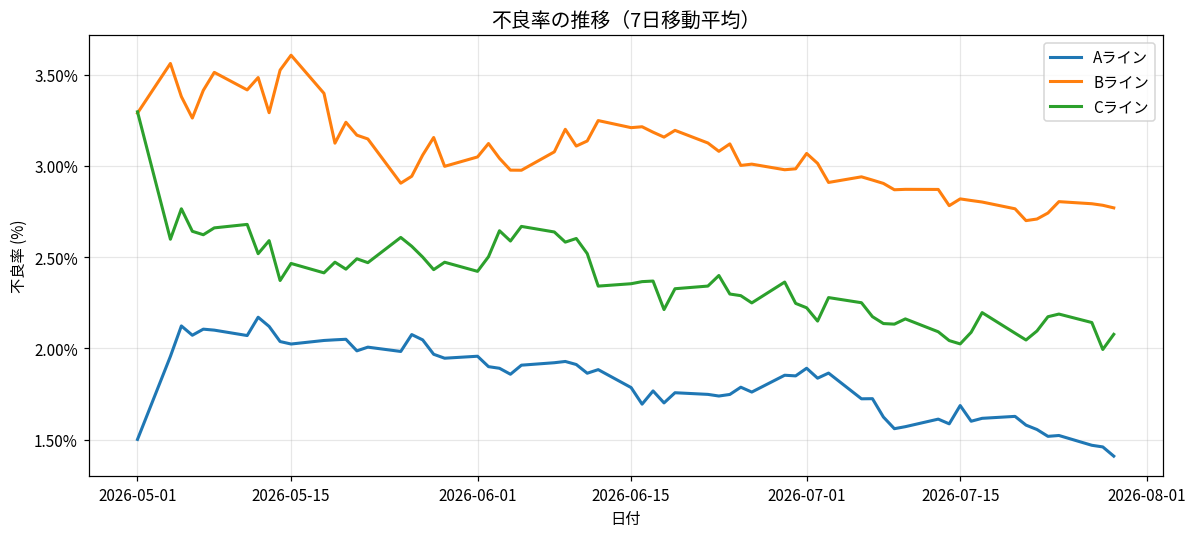

In [6]:

fig, ax = plt.subplots(figsize=(11, 5))

for line, grp in daily.groupby("line"):
    grp = grp.sort_values("date")
    ma7 = grp["defect_rate"].rolling(7, min_periods=1).mean()
    ax.plot(grp["date"], ma7 * 100, label=line, linewidth=2)

ax.set_title("不良率の推移（7日移動平均）", fontsize=13)
ax.set_xlabel("日付")
ax.set_ylabel("不良率 (%)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("../images/defect_rate_trend.png")
plt.show()



**読み取れること**：3ラインとも期間を通じて不良率がゆるやかに低下する傾向にあります。
一方でBラインは他の2ラインより不良率の水準自体が高く、改善の余地が大きいことが分かります。


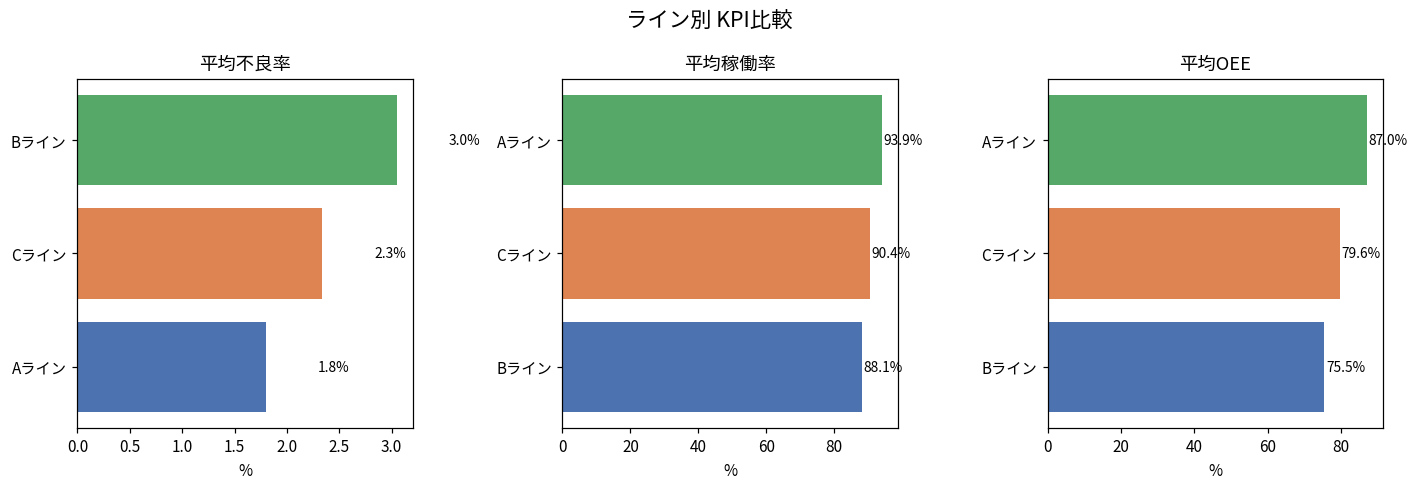

In [7]:

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))

metrics = [("defect_rate", "平均不良率"), ("availability", "平均稼働率"), ("oee", "平均OEE")]
colors = ["#4C72B0", "#DD8452", "#55A868"]

for ax, (col, title) in zip(axes, metrics):
    vals = (summary[col] * 100).sort_values()
    ax.barh(vals.index, vals.values, color=colors)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("%")
    for i, v in enumerate(vals.values):
        ax.text(v + 0.5, i, f"{v:.1f}%", va="center", fontsize=9)

fig.suptitle("ライン別 KPI比較", fontsize=14)
fig.tight_layout()
fig.savefig("../images/line_comparison.png")
plt.show()


## 4. 不良原因のパレート分析

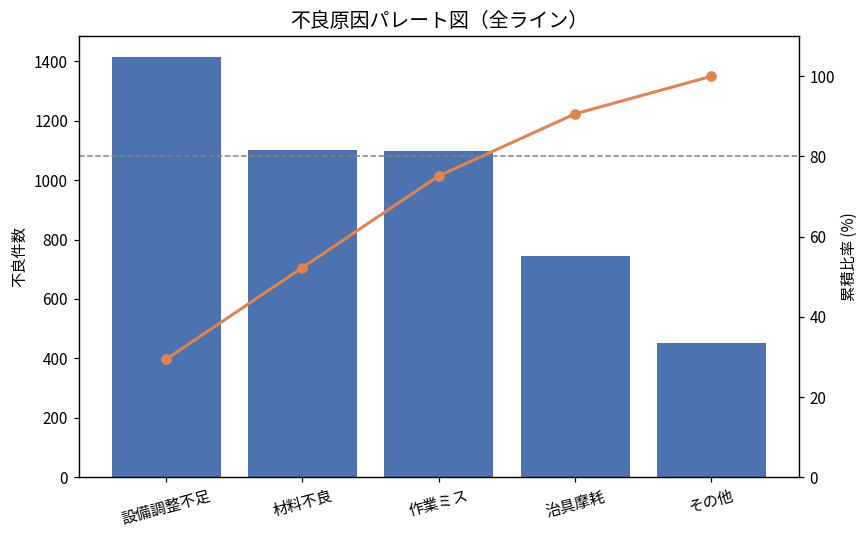

defect_cause
設備調整不足    1414
材料不良      1101
作業ミス      1099
治具摩耗       744
その他        451
Name: count, dtype: int64

In [8]:

def plot_pareto(df, title, filename):
    cause_counts = df.groupby("defect_cause")["count"].sum().sort_values(ascending=False)
    cum_pct = cause_counts.cumsum() / cause_counts.sum() * 100

    fig, ax1 = plt.subplots(figsize=(8, 5))
    bars = ax1.bar(cause_counts.index, cause_counts.values, color="#4C72B0")
    ax1.set_ylabel("不良件数")
    ax1.set_title(title, fontsize=13)
    ax1.tick_params(axis="x", rotation=15)

    ax2 = ax1.twinx()
    ax2.plot(cause_counts.index, cum_pct.values, color="#DD8452", marker="o", linewidth=2)
    ax2.axhline(80, color="gray", linestyle="--", linewidth=1)
    ax2.set_ylabel("累積比率 (%)")
    ax2.set_ylim(0, 110)

    fig.tight_layout()
    fig.savefig(filename)
    plt.show()
    return cause_counts, cum_pct

overall_counts, overall_cum = plot_pareto(defects, "不良原因パレート図（全ライン）", "../images/pareto_overall.png")
overall_counts


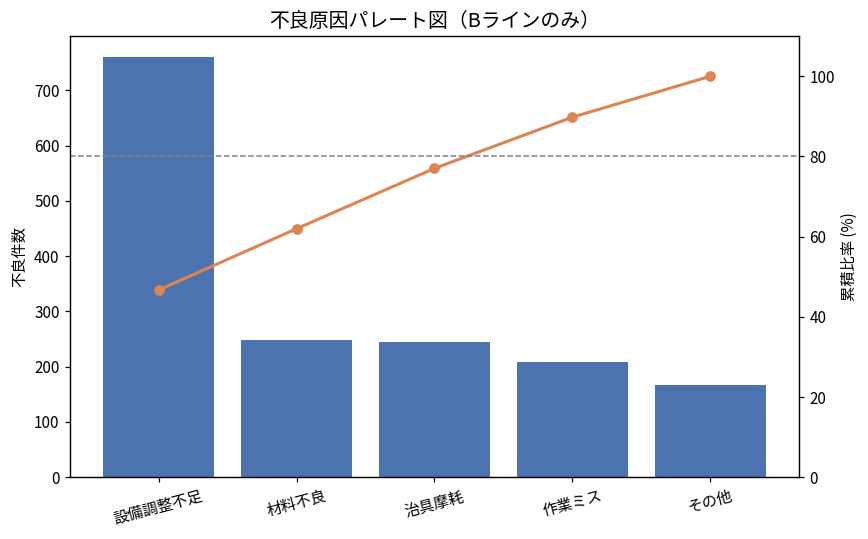

defect_cause
設備調整不足    760
材料不良      249
治具摩耗      245
作業ミス      208
その他       166
Name: count, dtype: int64

In [9]:

# Bラインだけ抽出して同様に分析（不良率が高い原因を掘り下げる）
b_line_defects = defects[defects["line"] == "Bライン"]
b_counts, b_cum = plot_pareto(b_line_defects, "不良原因パレート図（Bラインのみ）", "../images/pareto_bline.png")
b_counts



**読み取れること**：全体では「材料不良」と「作業ミス」が上位を占めますが、
Bラインに絞ると「設備調整不足」が突出して多いことが分かります。

これはBラインの稼働率がほかの2ラインより低い傾向とも整合しており、
**設備の予防保全・調整プロセスの見直しが、Bラインの不良率と稼働率を同時に改善する
レバレッジポイントになりそう**、という仮説が立てられます。


## 5. 週次OEEトレンド（ヒートマップ）

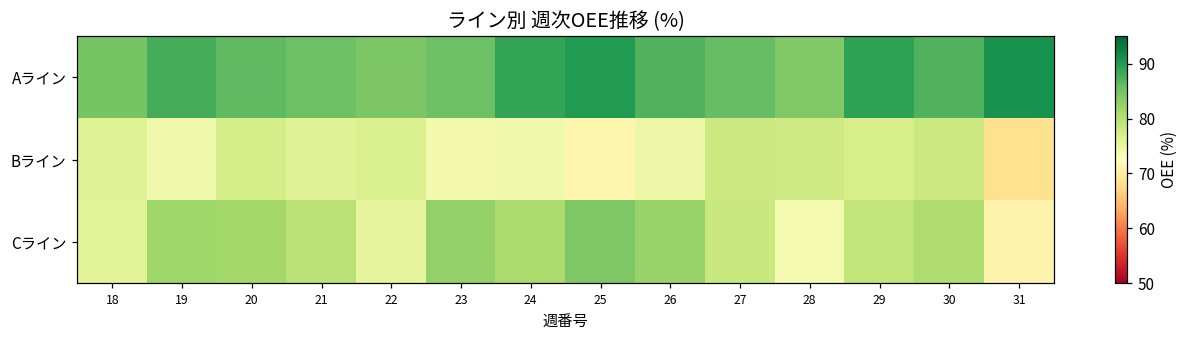

In [10]:

daily["week"] = daily["date"].dt.isocalendar().week
weekly_oee = daily.pivot_table(index="line", columns="week", values="oee", aggfunc="mean") * 100

fig, ax = plt.subplots(figsize=(12, 3.2))
im = ax.imshow(weekly_oee.values, aspect="auto", cmap="RdYlGn", vmin=50, vmax=95)
ax.set_yticks(range(len(weekly_oee.index)))
ax.set_yticklabels(weekly_oee.index)
ax.set_xticks(range(len(weekly_oee.columns)))
ax.set_xticklabels(weekly_oee.columns, fontsize=8)
ax.set_xlabel("週番号")
ax.set_title("ライン別 週次OEE推移 (%)", fontsize=13)
fig.colorbar(im, ax=ax, label="OEE (%)")
fig.tight_layout()
fig.savefig("../images/weekly_oee_heatmap.png")
plt.show()



## 6. 分析まとめ

- 3ラインとも期間中に不良率が緩やかに改善しており、日々の改善活動の効果が数値上も見て取れる。
- **Bラインは他ラインよりOEE・稼働率が低く、不良原因も「設備調整不足」に偏っている**。
  設備の予防保全計画を見直すことで、不良率と稼働率の両方に効く可能性が高い。
- 週次OEEヒートマップでは、特定の週に複数ラインで同時にOEEが落ち込む週が見られる
  （例：設備の定期点検やライン休止と重なった可能性）。実データがあれば、
  保全記録と突き合わせて要因を特定できる。

## 今後やりたいこと

- 実データ（またはより現実に近いデータ）での再検証
- FastAPIでこの分析をAPI化し、日次データをアップロードすると自動でKPIレポートが
  生成される仕組みを作る（現在学習中のFastAPIと接続予定）
- 異常検知（急な不良率上昇の自動アラート）の実装

## 学びメモ（lessons learned）

- `pandas` の `groupby` + `pivot_table` で、集計軸を変えながら複数の切り口から
  同じデータを見る練習になった。
- パレート図（棒グラフ＋累積折れ線の二軸グラフ）を`matplotlib`のtwinx()で描く方法を習得。
- 日本語フォントが可視化ツールでうまく表示されない問題（いわゆる「文字化け（豆腐）」）に遭遇し、
  `Noto Sans CJK JP` フォントを指定することで解決した。
